In [10]:
import pandas as pd
import numpy as np
import re
import string

import nltk
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("punkt")
nltk.download('punkt_tab')
nltk.download("omw-1.4")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import matplotlib.pyplot as plt

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


#1. Load the Dataset

In [3]:
data = pd.read_csv(
    "/content/drive/MyDrive/AI and ML/trum_tweet_sentiment_analysis.csv",
    encoding="ISO-8859-1"
)

data.head()

,text,Sentiment
0,RT @JohnLeguizamo: #trump not draining swamp b...,0
1,ICYMI: Hackers Rig FM Radio Stations To Play A...,0
2,Trump protests: LGBTQ rally in New York https:...,1
3,"""Hi I'm Piers Morgan. David Beckham is awful b...",0
4,RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...,0


In [5]:
print(data.shape)
print(data.columns)


(1850123, 2)
Index(['text', 'Sentiment'], dtype='object')


#2. Text Cleaning and Tokenization

In [6]:
data = data[["text", "Sentiment"]]

data = data.dropna(subset=["text", "Sentiment"])

print(data.shape)
data.head()

(1850123, 2)


,text,Sentiment
0,RT @JohnLeguizamo: #trump not draining swamp b...,0
1,ICYMI: Hackers Rig FM Radio Stations To Play A...,0
2,Trump protests: LGBTQ rally in New York https:...,1
3,"""Hi I'm Piers Morgan. David Beckham is awful b...",0
4,RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...,0


cleaning helper functions

In [7]:
stop_words = set(stopwords.words("english"))

def lower_order(text):
    return str(text).lower()

def remove_urls(text):
    url_pattern = re.compile(r"https?://\S+|www\.\S+")
    return url_pattern.sub("", text)

def remove_emoji(text):
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub(" ", text)

def removeunwanted_characters(text):
    text = re.sub(r"@[A-Za-z0-9_]+", " ", text)
    text = re.sub(r"#[A-Za-z0-9_]+", " ", text)
    text = re.sub(r"[^A-Za-z ]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

def lemmatization(tokens):
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(word, pos="v") for word in tokens]

def stemming(tokens):
    stemmer = PorterStemmer()
    return [stemmer.stem(word) for word in tokens]

In [8]:
#Text cleaning pipeline
def text_cleaning_pipeline(dataset, rule="lemmatize"):
    """
    This function cleans text data using lowercasing, URL removal,
    emoji removal, unwanted character removal, stopword removal
    and lemmatization or stemming.
    """

    data = str(dataset)

    # Convert the input to small/lower order
    data = lower_order(data)

    # Remove URLs
    data = remove_urls(data)

    # Remove emojis
    data = remove_emoji(data)

    # Remove mentions, hashtags, punctuation and special characters
    data = removeunwanted_characters(data)

    # Create tokens
    tokens = word_tokenize(data)

    # Remove stopwords
    tokens = remove_stopwords(tokens)

    if rule == "lemmatize":
        tokens = lemmatization(tokens)

    elif rule == "stem":
        tokens = stemming(tokens)

    else:
        print("Pick between lemmatize or stem")

    return " ".join(tokens)

In [11]:
data["cleaned_text"] = data["text"].apply(lambda x: text_cleaning_pipeline(x, rule="lemmatize"))

data[["text", "cleaned_text", "Sentiment"]].head()

,text,cleaned_text,Sentiment
0,RT @JohnLeguizamo: #trump not draining swamp b...,rt drain swamp taxpayer dollars trip advertise...,0
1,ICYMI: Hackers Rig FM Radio Stations To Play A...,icymi hackers rig fm radio station play anti t...,0
2,Trump protests: LGBTQ rally in New York https:...,trump protest lgbtq rally new york via,1
3,"""Hi I'm Piers Morgan. David Beckham is awful b...",hi piers morgan david beckham awful donald tru...,0
4,RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...,rt tech firm sue buzzfeed publish unverified t...,0


In [12]:
data["Sentiment"].value_counts()

,count
Sentiment,
0,1244211
1,605912


#3. Train-Test Split

In [13]:
X = data["cleaned_text"]
y = data["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1480098,)
Testing data: (370025,)


#4. TF-IDF Vectorization

In [14]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (1480098, 5000)
Testing TF-IDF shape: (370025, 5000)


#5. Model Training and Evaluation

In [15]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

print("Model training completed.")

Model training completed.


In [16]:
y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.918767650834403

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94    248842
           1       0.89      0.85      0.87    121183

    accuracy                           0.92    370025
   macro avg       0.91      0.90      0.91    370025
weighted avg       0.92      0.92      0.92    370025



In [17]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[236705  12137]
 [ 17921 103262]]


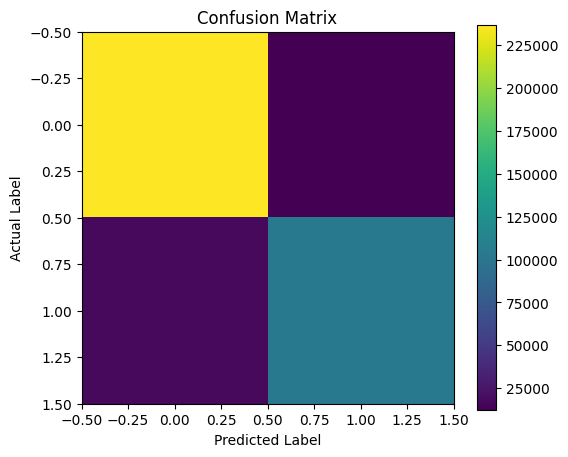

In [18]:
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.colorbar()
plt.show()